# 📊 Notebook 04: Feature Engineering — Statistical Features

---

## 🎯 Objective

While technical indicators (NB03) focus on *price patterns*, statistical features capture the *distributional properties* of returns. These features help ML models understand:
- **How volatile** is the stock right now vs historically?
- **Are returns normally distributed** or is there tail risk?
- **Is the current price "normal"** or an extreme deviation?

### Features We'll Build:
| Feature | What It Measures | Why It Matters |
|---------|-----------------|----------------|
| Log Returns | Continuously compounded return | Better for modeling than simple returns |
| Rolling Volatility | Recent price variability | High vol = uncertain market |
| Rolling Skewness | Asymmetry of returns | Negative skew = more crash risk |
| Rolling Kurtosis | Tail heaviness | High kurtosis = extreme events more likely |
| Z-Score | Standard deviations from mean | Mean reversion signal |
| Price x Volume | Dollar volume | Liquidity measure |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

PROCESSED_DIR = '../data/processed'
print("Environment ready")

Environment ready


## 1. Load Technical Data

In [2]:
# Load data with technical indicators from NB03
filepath = os.path.join(PROCESSED_DIR, 'tata_motors_with_technicals.csv')
if os.path.exists(filepath):
    df = pd.read_csv(filepath, index_col=0, parse_dates=True)
    print(f"Loaded: {df.shape}")
else:
    # Fallback to clean data
    df = pd.read_csv(os.path.join(PROCESSED_DIR, 'tata_motors_clean.csv'), index_col=0, parse_dates=True)
    print(f"Loaded (fallback): {df.shape}")

df.head()

Loaded: (85, 30)


,Close,High,Low,Open,Volume,Regime,Returns,Price_Change,Gain,Loss,...,BB_Std,BB_Upper,BB_Lower,BB_Width,BB_Upper_Touch,BB_Lower_Touch,OBV,OBV_Normalized,TR,ATR_14
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-15,390.850006,403.000000,388.000000,403.000000,26953550,Oct 2024 Crash,NaN,NaN,0.000000,0.000000,...,NaN,NaN,NaN,NaN,False,False,0.0,77.336215,NaN,NaN
2025-10-16,396.799988,400.450012,389.549988,395.450012,21983750,Oct 2024 Crash,0.015223,5.949982,5.949982,0.000000,...,NaN,NaN,NaN,NaN,False,False,21983750.0,87.416855,10.900024,NaN
2025-10-17,396.600006,402.500000,392.250000,396.799988,16564540,Oct 2024 Crash,-0.000504,-0.199982,0.000000,0.199982,...,NaN,NaN,NaN,NaN,False,False,5419210.0,79.821191,10.250000,NaN
2025-10-20,399.750000,403.399994,396.600006,400.049988,10471670,Oct 2024 Crash,0.007942,3.149994,3.149994,0.000000,...,NaN,NaN,NaN,NaN,False,False,15890880.0,84.622972,6.799988,NaN
2025-10-21,401.850006,403.399994,400.049988,402.799988,3449156,Oct 2024 Crash,0.005253,2.100006,2.100006,0.000000,...,NaN,NaN,NaN,NaN,False,False,19340036.0,86.204581,3.649994,NaN


## 2. Log Returns

### Why Log Returns Instead of Simple Returns?

**Simple Return:** $R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$

**Log Return:** $r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$

**Advantages of Log Returns:**
1. **Additive over time:** $r_{total} = r_1 + r_2 + ... + r_n$ (simple returns are multiplicative)
2. **Approximately normal distributed** — better for statistical modeling
3. **Symmetric:** A +10% log return exactly offsets a -10% log return (simple returns don't!)

**Approximation:** For small returns (<10%), $r_t \approx R_t$


In [3]:
# Calculate both types of returns for comparison
df['Simple_Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Compare
print("SIMPLE vs LOG RETURNS COMPARISON")
print("=" * 50)
comparison = pd.DataFrame({
    'Simple Mean': [df['Simple_Return'].mean()],
    'Log Mean': [df['Log_Return'].mean()],
    'Simple Std': [df['Simple_Return'].std()],
    'Log Std': [df['Log_Return'].std()],
    'Correlation': [df['Simple_Return'].corr(df['Log_Return'])]
}).T
comparison.columns = ['Value']
print(comparison.round(6))
print(f"\nCorrelation between simple and log returns: {df['Simple_Return'].corr(df['Log_Return']):.6f}")
print("(Near 1.0 for small daily returns, as expected)")

SIMPLE vs LOG RETURNS COMPARISON
                Value
Simple Mean -0.000150
Log Mean    -0.000246
Simple Std   0.013956
Log Std      0.013969
Correlation  0.999929

Correlation between simple and log returns: 0.999929
(Near 1.0 for small daily returns, as expected)


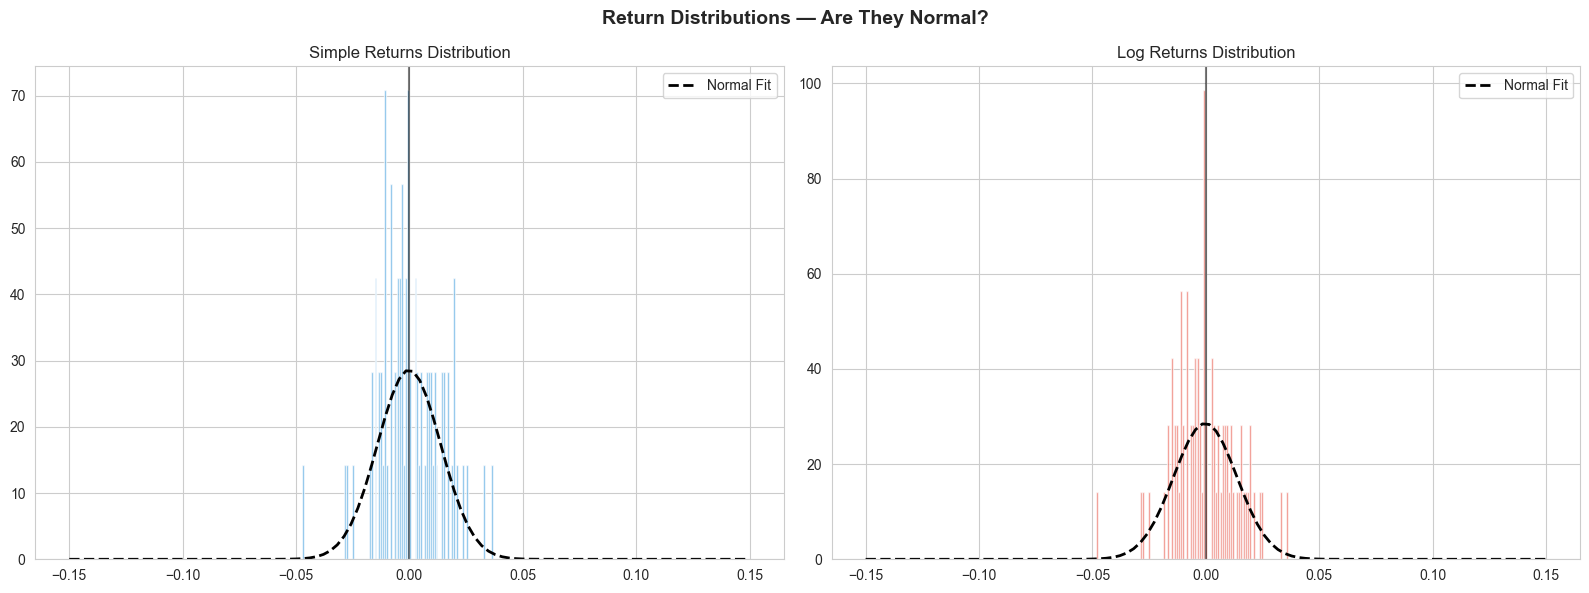


Jarque-Bera Test: statistic=3.78, p-value=0.151448
Normal? Yes


In [4]:
# Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['Simple_Return'].dropna(), bins=100, color='#3498DB', alpha=0.7, edgecolor='white', density=True)
axes[0].set_title('Simple Returns Distribution')
axes[0].axvline(0, color='black', linestyle='-', alpha=0.5)

axes[1].hist(df['Log_Return'].dropna(), bins=100, color='#E74C3C', alpha=0.7, edgecolor='white', density=True)
axes[1].set_title('Log Returns Distribution')
axes[1].axvline(0, color='black', linestyle='-', alpha=0.5)

# Overlay normal distribution
x = np.linspace(-0.15, 0.15, 100)
for i, col in enumerate(['Simple_Return', 'Log_Return']):
    mu, sigma = df[col].mean(), df[col].std()
    axes[i].plot(x, stats.norm.pdf(x, mu, sigma), 'k--', linewidth=2, label='Normal Fit')
    axes[i].legend()

plt.suptitle('Return Distributions — Are They Normal?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Normality test
stat, p = stats.jarque_bera(df['Log_Return'].dropna())
print(f"\nJarque-Bera Test: statistic={stat:.2f}, p-value={p:.6f}")
print(f"Normal? {'Yes' if p > 0.05 else 'No — returns have fat tails (expected for stocks)'}")

## 3. Rolling Volatility

Volatility is the **standard deviation of returns** over a rolling window. It tells us how "wild" the price moves are.

**Annualized Volatility:**
$$\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$$

Where 252 = number of trading days per year.

**Windows:**
- 21 days ~ 1 month (short-term trading decisions)
- 63 days ~ 1 quarter (portfolio rebalancing)


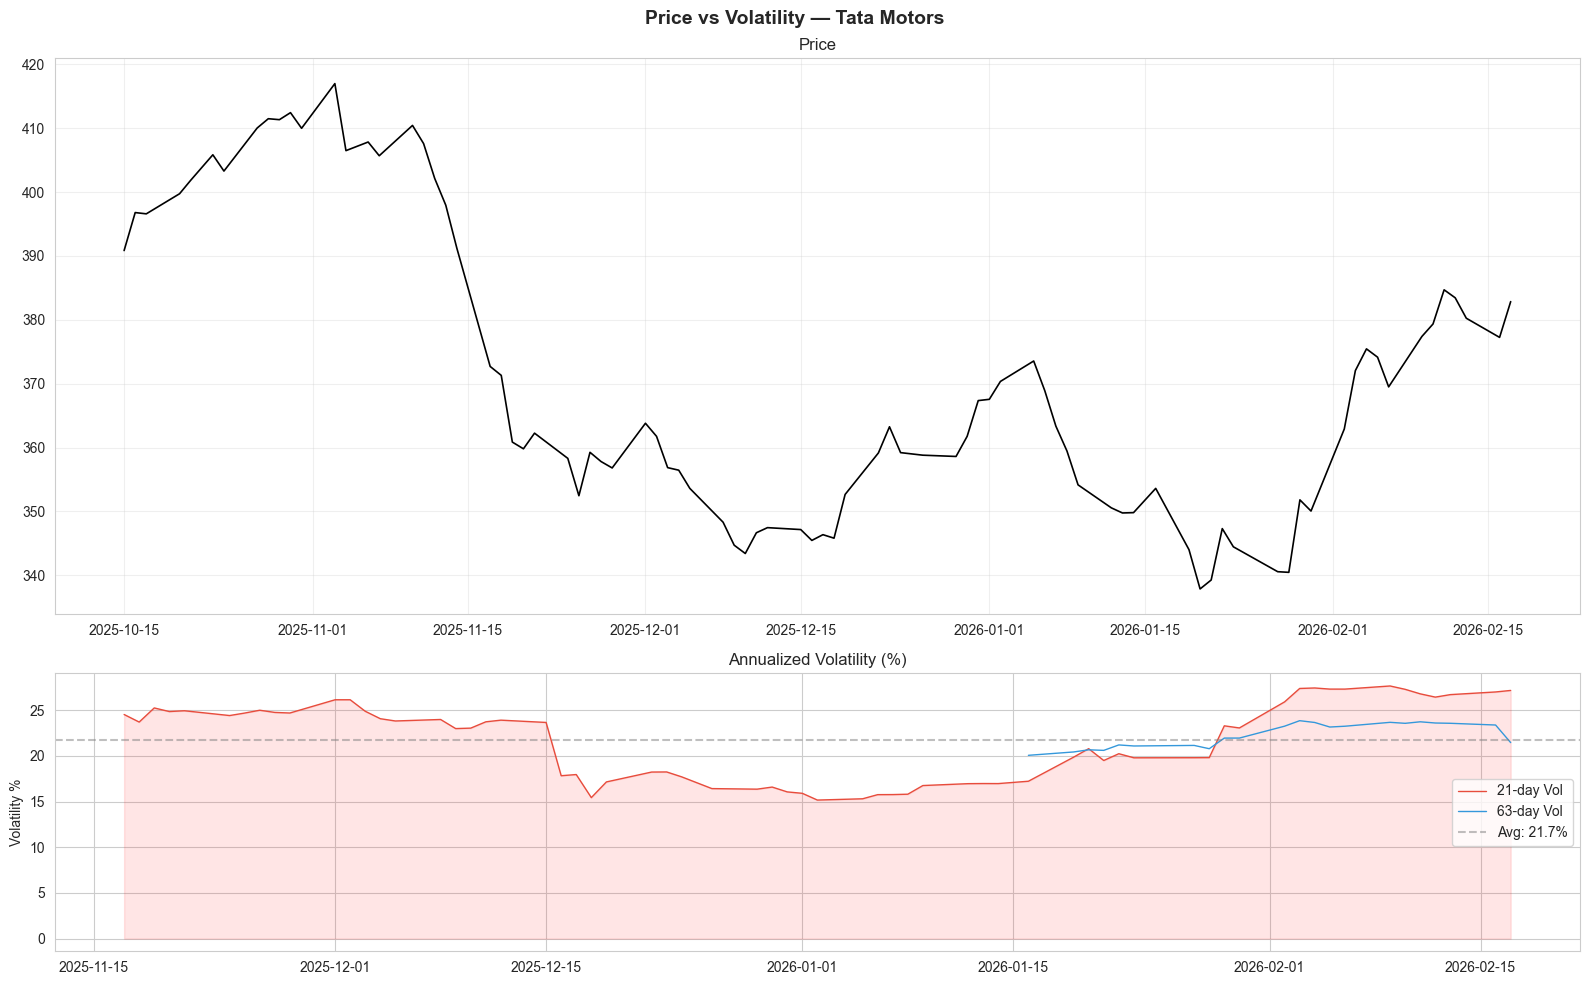

Current 21d Vol: 27.1%
Average Vol: 21.7%
Max Vol (COVID): 27.6%


In [5]:
# Calculate rolling volatility
df['Vol_21d'] = df['Log_Return'].rolling(window=21).std() * np.sqrt(252)
df['Vol_63d'] = df['Log_Return'].rolling(window=63).std() * np.sqrt(252)

# Historical average
avg_vol = df['Vol_21d'].mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

# Price
axes[0].plot(df.index, df['Close'], color='black', linewidth=1.2)
axes[0].set_title('Price', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Volatility
axes[1].plot(df.index, df['Vol_21d'] * 100, color='#E74C3C', linewidth=1, label='21-day Vol')
axes[1].plot(df.index, df['Vol_63d'] * 100, color='#3498DB', linewidth=1, label='63-day Vol')
axes[1].axhline(avg_vol * 100, color='gray', linestyle='--', alpha=0.5, label=f'Avg: {avg_vol*100:.1f}%')
axes[1].set_title('Annualized Volatility (%)', fontsize=12)
axes[1].set_ylabel('Volatility %')
axes[1].legend()
axes[1].fill_between(df.index, 0, df['Vol_21d'] * 100, alpha=0.1, color='red')

plt.suptitle('Price vs Volatility — Tata Motors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Current 21d Vol: {df['Vol_21d'].iloc[-1]*100:.1f}%")
print(f"Average Vol: {avg_vol*100:.1f}%")
print(f"Max Vol (COVID): {df['Vol_21d'].max()*100:.1f}%")

## 4. Rolling Skewness & Kurtosis

### Skewness: Is the Distribution Symmetric?
$$\text{Skewness} = \frac{E[(X - \mu)^3]}{\sigma^3}$$

- **Negative skew:** Left tail is longer (crash risk!) — common in stocks
- **Zero skew:** Symmetric (normal distribution)
- **Positive skew:** Right tail is longer (upside potential)

### Kurtosis: How Heavy Are the Tails?
$$\text{Kurtosis} = \frac{E[(X - \mu)^4]}{\sigma^4}$$

- **Kurtosis = 3:** Normal distribution (mesokurtic)
- **Kurtosis > 3:** Fat tails — extreme events happen more often (leptokurtic)
- **Kurtosis < 3:** Thin tails — extreme events are rarer (platykurtic)

> **Stock markets almost always have kurtosis > 3**, which means crashes are more likely than a normal distribution predicts. This is why risk models that assume normality underestimate tail risk!


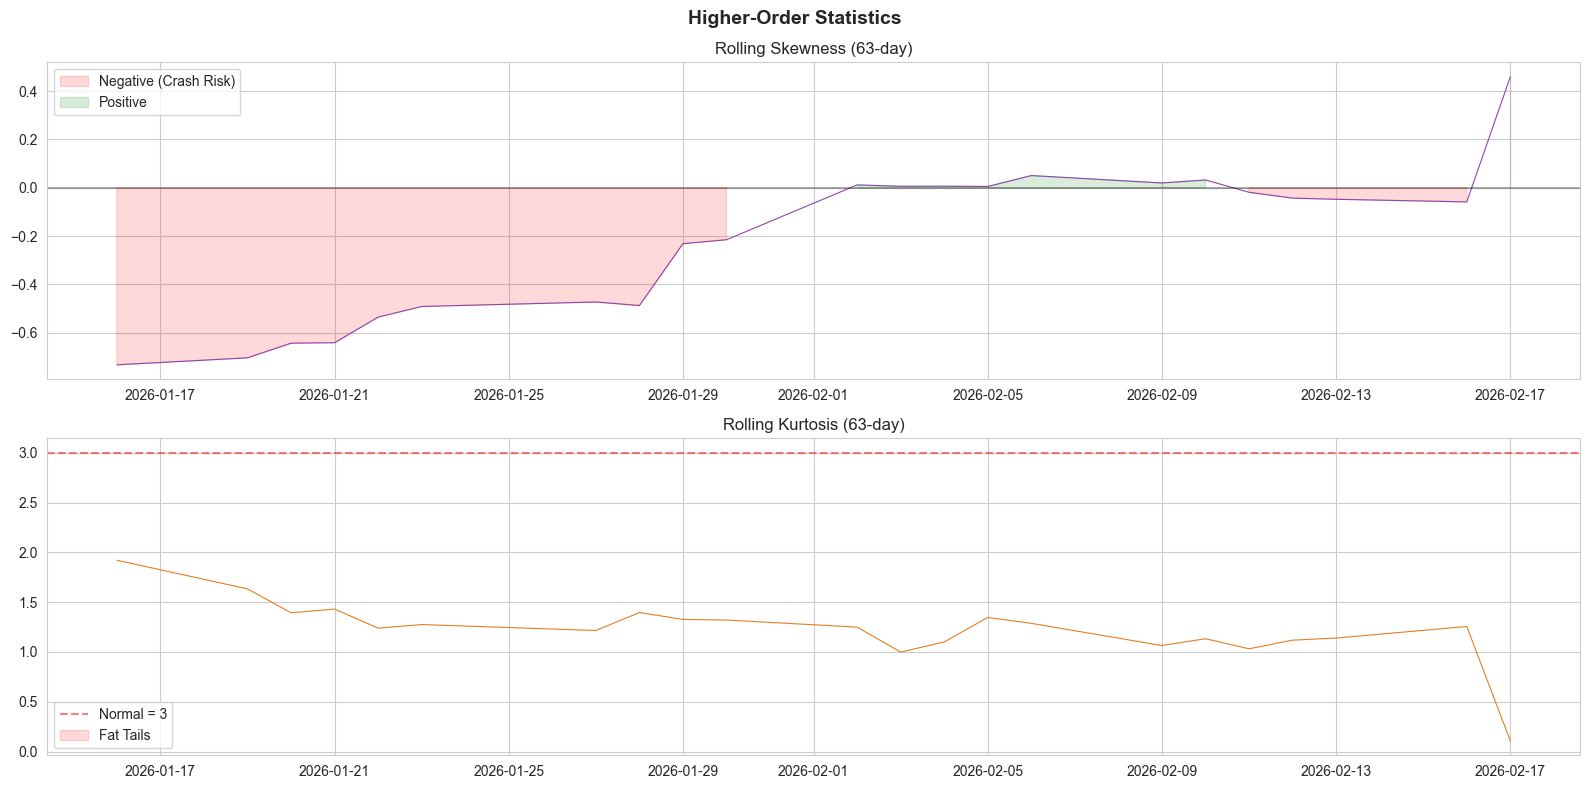

Average Skewness: -0.215 (Negative = crash bias)
Average Kurtosis: 1.226 (Near normal)


In [6]:
# Rolling skewness and kurtosis (63-day window)
df['Skew_63d'] = df['Log_Return'].rolling(window=63).skew()
df['Kurt_63d'] = df['Log_Return'].rolling(window=63).kurt()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Skewness
ax = axes[0]
ax.plot(df.index, df['Skew_63d'], color='#8E44AD', linewidth=0.8)
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.fill_between(df.index, 0, df['Skew_63d'], where=df['Skew_63d'] < 0, alpha=0.15, color='red', label='Negative (Crash Risk)')
ax.fill_between(df.index, 0, df['Skew_63d'], where=df['Skew_63d'] > 0, alpha=0.15, color='green', label='Positive')
ax.set_title('Rolling Skewness (63-day)')
ax.legend()

# Kurtosis
ax = axes[1]
ax.plot(df.index, df['Kurt_63d'], color='#E67E22', linewidth=0.8)
ax.axhline(3, color='red', linestyle='--', alpha=0.5, label='Normal = 3')
ax.fill_between(df.index, 3, df['Kurt_63d'], where=df['Kurt_63d'] > 3, alpha=0.15, color='red', label='Fat Tails')
ax.set_title('Rolling Kurtosis (63-day)')
ax.legend()

plt.suptitle('Higher-Order Statistics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average Skewness: {df['Skew_63d'].mean():.3f} ({'Negative = crash bias' if df['Skew_63d'].mean() < 0 else 'Positive'})")
print(f"Average Kurtosis: {df['Kurt_63d'].mean():.3f} ({'Fat tails!' if df['Kurt_63d'].mean() > 3 else 'Near normal'})")

## 5. Z-Score — Mean Reversion Signal

### Theory
The Z-Score measures how many standard deviations the current price is from its mean.

$$Z = \frac{P_t - \mu_{n}}{\sigma_{n}}$$

**Trading Logic:**
- Z > 2: Price is 2+ standard deviations ABOVE mean — potentially overvalued
- Z < -2: Price is 2+ standard deviations BELOW mean — potentially undervalued
- This is the basis of **mean reversion** strategies

> **Caveat:** Mean reversion assumes prices return to their average. This works for range-bound stocks but fails during trending markets or structural shifts.


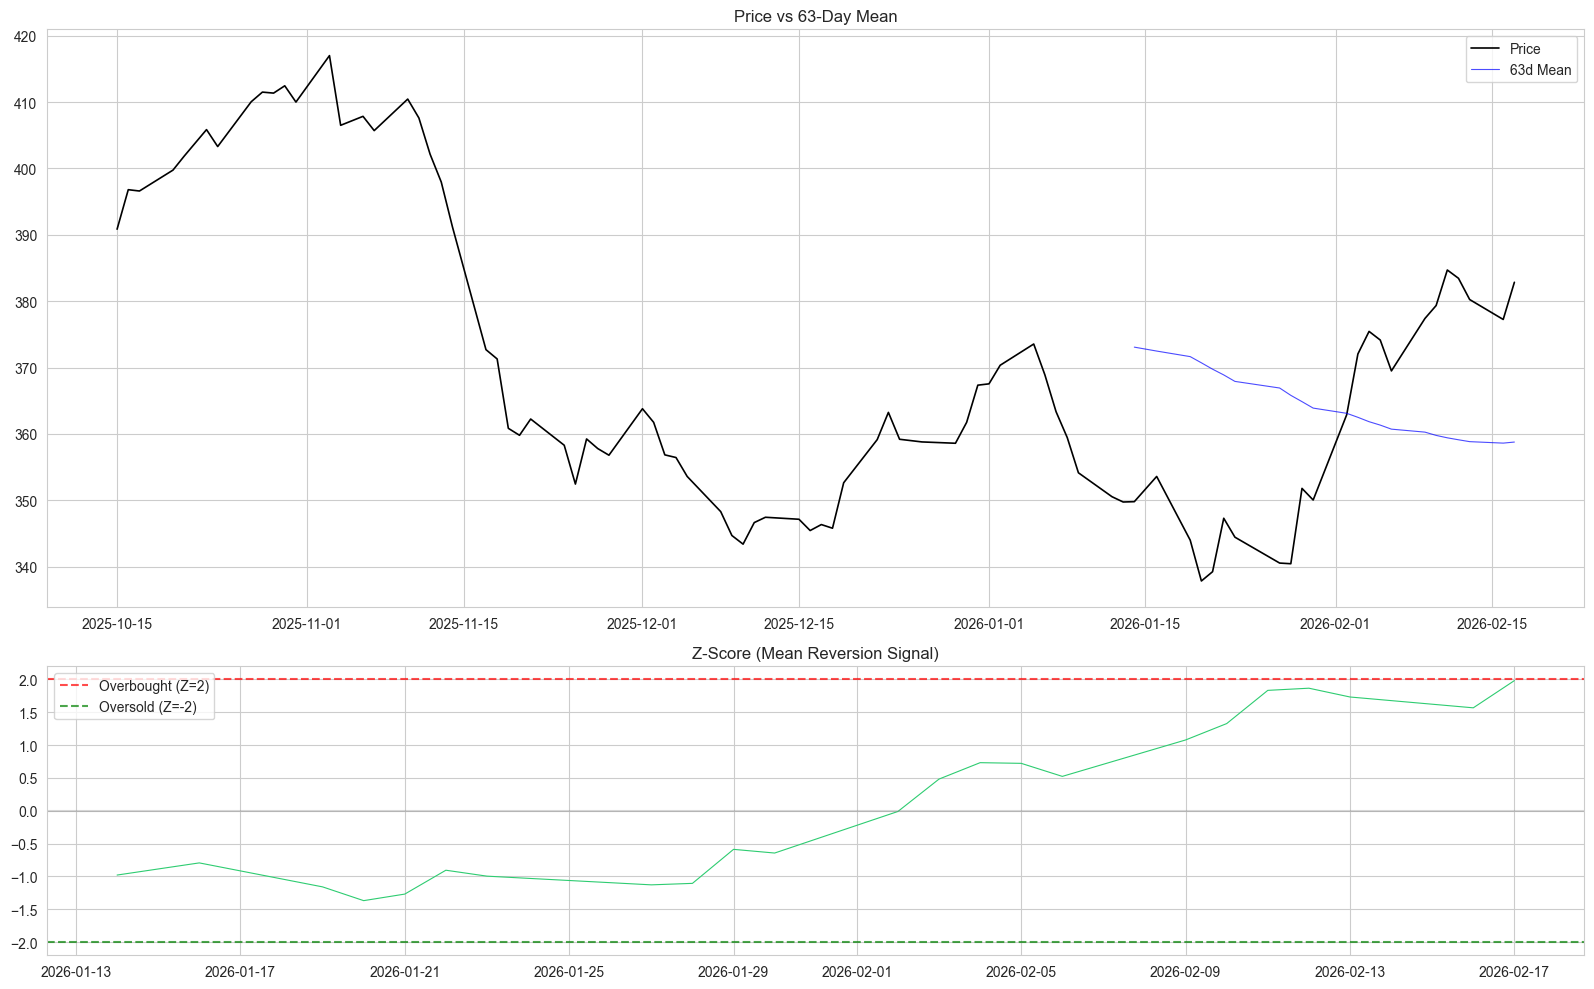

Days with Z > 2 (overbought): 0
Days with Z < -2 (oversold): 0


In [7]:
# Z-Score (63-day rolling)
df['Price_Mean_63'] = df['Close'].rolling(window=63).mean()
df['Price_Std_63'] = df['Close'].rolling(window=63).std()
df['Z_Score'] = (df['Close'] - df['Price_Mean_63']) / df['Price_Std_63']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

# Price with mean
ax = axes[0]
ax.plot(df.index, df['Close'], color='black', linewidth=1.2, label='Price')
ax.plot(df.index, df['Price_Mean_63'], color='blue', linewidth=0.8, alpha=0.7, label='63d Mean')
ax.set_title('Price vs 63-Day Mean')
ax.legend()

# Z-Score
ax = axes[1]
ax.plot(df.index, df['Z_Score'], color='#2ECC71', linewidth=0.8)
ax.axhline(2, color='red', linestyle='--', alpha=0.7, label='Overbought (Z=2)')
ax.axhline(-2, color='green', linestyle='--', alpha=0.7, label='Oversold (Z=-2)')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.fill_between(df.index, 2, df['Z_Score'], where=df['Z_Score'] > 2, alpha=0.2, color='red')
ax.fill_between(df.index, -2, df['Z_Score'], where=df['Z_Score'] < -2, alpha=0.2, color='green')
ax.set_title('Z-Score (Mean Reversion Signal)')
ax.legend()

plt.tight_layout()
plt.show()

# Count extreme Z-Scores
print(f"Days with Z > 2 (overbought): {(df['Z_Score'] > 2).sum()}")
print(f"Days with Z < -2 (oversold): {(df['Z_Score'] < -2).sum()}")

## 6. Interaction Features

These combine multiple data streams to create new signals:

| Feature | Formula | Meaning |
|---------|---------|---------|
| Dollar Volume | Price x Volume | Total trading activity in rupees |
| Range/Volume | (High-Low) / Volume | Price impact per unit volume |
| Return/Volume | \|Return\| / Volume | How much volume it takes to move price |


In [8]:
# Interaction features
df['Dollar_Volume'] = df['Close'] * df['Volume']
df['Range'] = df['High'] - df['Low']
df['Range_per_Volume'] = df['Range'] / (df['Volume'] / 1e6)  # Range per million shares
df['Abs_Return_per_Volume'] = df['Log_Return'].abs() / (df['Volume'] / 1e6)

print("Interaction Features Summary:")
print(df[['Dollar_Volume', 'Range_per_Volume', 'Abs_Return_per_Volume']].describe().round(4))

Interaction Features Summary:
       Dollar_Volume  Range_per_Volume  Abs_Return_per_Volume
count   8.500000e+01           85.0000                84.0000
mean    4.426779e+09            0.7622                 0.0009
std     3.014009e+09            0.2652                 0.0007
min     1.386043e+09            0.1053                 0.0000
25%     3.082040e+09            0.6105                 0.0004
50%     3.622946e+09            0.7243                 0.0009
75%     4.779896e+09            0.9022                 0.0015
max     2.611471e+10            1.4472                 0.0029


## 7. Feature Correlation Analysis

Before feeding features into ML models, we check for **multicollinearity** — features that are too highly correlated with each other provide redundant information and can destabilize models.

**Rule of thumb:** Drop features with correlation > 0.9 (covered in NB09)


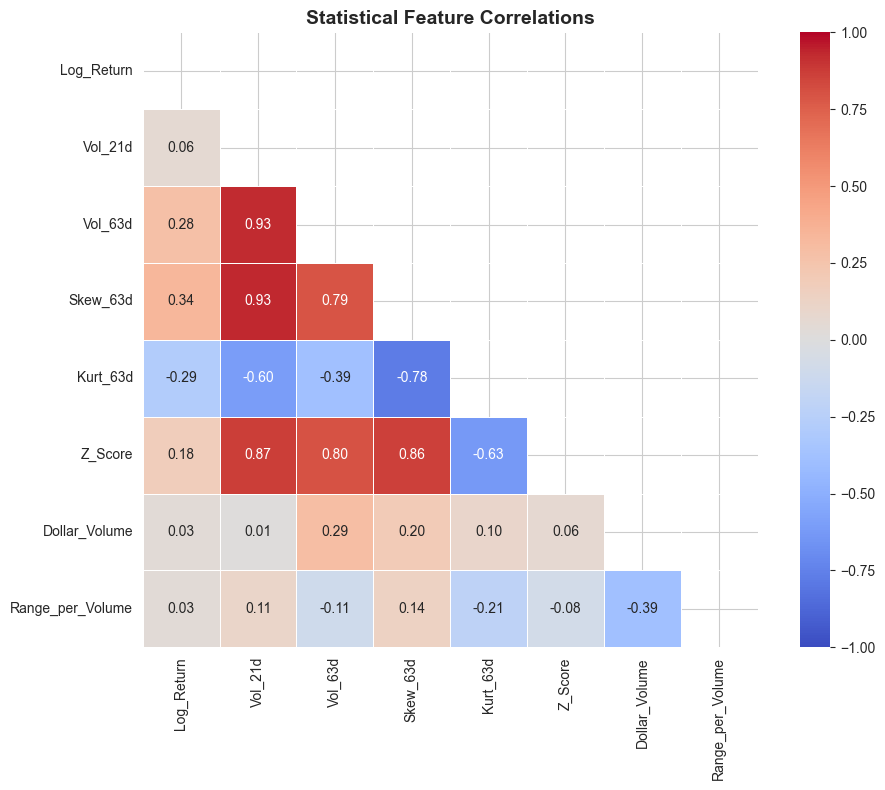


Highly Correlated Pairs (|r| > 0.8):
  Vol_21d <-> Vol_63d: 0.926
  Vol_21d <-> Skew_63d: 0.932
  Vol_21d <-> Z_Score: 0.868
  Vol_63d <-> Z_Score: 0.801
  Skew_63d <-> Z_Score: 0.859


In [9]:
# Select statistical features for correlation
stat_features = ['Log_Return', 'Vol_21d', 'Vol_63d', 'Skew_63d', 'Kurt_63d', 
                 'Z_Score', 'Dollar_Volume', 'Range_per_Volume']
existing = [f for f in stat_features if f in df.columns]

corr = df[existing].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
ax.set_title('Statistical Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
print("\nHighly Correlated Pairs (|r| > 0.8):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.8:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i,j]:.3f}")

In [10]:
# Save with all features
df.to_csv(os.path.join(PROCESSED_DIR, 'tata_motors_all_features.csv'))
print(f"Saved: tata_motors_all_features.csv")
print(f"Total columns: {len(df.columns)}")
print(f"New statistical features: {[c for c in df.columns if c in stat_features]}")

Saved: tata_motors_all_features.csv
Total columns: 43
New statistical features: ['Log_Return', 'Vol_21d', 'Vol_63d', 'Skew_63d', 'Kurt_63d', 'Z_Score', 'Dollar_Volume', 'Range_per_Volume']


---

## 📌 Phase 2 Insight: Rolling Statistics Teach "Normal"

> **The Data Scientist says:** *"I create vectors that represent momentum and mean reversion."*

### What Rolling Statistics Do
Calculate `rolling_mean` and `rolling_std` over **20-day and 50-day** windows. This teaches the ML model what "normal" behaviour looks like for each period:

- **Rolling Mean (20d):** Short-term trend anchor
- **Rolling Mean (50d):** Medium-term trend anchor
- **Rolling Std (20d):** Recent volatility (is the stock calm or excited?)
- **Rolling Std (50d):** Medium-term volatility baseline

A price that is 2σ above its 20-day rolling mean is exhibiting **unusual behaviour** — and that deviation itself becomes a powerful feature.

### Z-Score Normalization
$$Z_t = \frac{P_t - \text{RollingMean}_{20}}{\text{RollingStd}_{20}}$$

This standardized deviation tells the model "how many standard deviations away from normal is today's price?" — a regime-independent, scale-free feature.


## 8. Summary

### Statistical Features Added:
| Feature | Window | Purpose |
|---------|--------|---------|
| Log Return | 1 day | Modeling-friendly return measure |
| Volatility | 21d, 63d | Risk assessment |
| Skewness | 63d | Crash probability indicator |
| Kurtosis | 63d | Tail risk measure |
| Z-Score | 63d | Mean reversion signal |
| Dollar Volume | 1 day | Liquidity proxy |

### Key Insight:
Returns are NOT normally distributed — they have **negative skewness** (crash bias) and **excess kurtosis** (fat tails). Any model that assumes normality will UNDERESTIMATE risk.

---
*Next: Notebook 05 — EDA, Trends & Regimes*
